# ML-Based Network Intrusion Detection System (KNN)

In this notebook, I built a simple beginner-friendly intrusion detection pipeline using the NSL-KDD dataset.

---
## Q1. Understanding the Dataset

This dataset belongs to the cybersecurity domain, specifically network intrusion detection.

The target column is class_label, where each value represents a type of normal traffic or attack.

The file has 43 columns in total:
- 3 categorical columns: protocol_type, service, flag
- 40 numeric columns (including difficulty_level and class_label)

---
## Q2.Load the dataset, Dropping and replacing NULL values 

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load the NSL-KDD training dataset
df = pd.read_csv(r"c:\Users\yugpa\Desktop\NIDS_Project\data\raw\KDDTrain+.txt", header=None)

# Assign all dataset column names
df.columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "difficulty_level", "class_label"
]

print("Dataset shape:", df.shape)
df.head()



Dataset shape: (125973, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty_level,class_label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [2]:
print("Total missing values:", int(df.isnull().sum().sum()))

# Keep all rows and fill missing values where needed.
df_basic = df.copy()

missing_before = int(df_basic.isnull().sum().sum())

categorical_cols = df_basic.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df_basic.select_dtypes(exclude=["object"]).columns.tolist()

for col in categorical_cols:
    if df_basic[col].isnull().any():
        df_basic[col] = df_basic[col].fillna(df_basic[col].mode()[0])

for col in numerical_cols:
    if df_basic[col].isnull().any():
        df_basic[col] = df_basic[col].fillna(df_basic[col].median())

missing_after = int(df_basic.isnull().sum().sum())
print("Before cleaning, missing values were:", missing_before)
print("After cleaning, missing values are:", missing_after)
print("Dataset shape after cleaning:", df_basic.shape)

Total missing values: 0
Before cleaning, missing values were: 0
After cleaning, missing values are: 0
Dataset shape after cleaning: (125973, 43)


---
## Q3. Basic Statistical Analysis

In [3]:
# Display basic stats for selected numeric columns.
basic_stats_cols = ["duration", "src_bytes", "dst_bytes", "count", "srv_count"]

stats_table = df_basic[basic_stats_cols].describe().T[["count", "mean", "std", "min", "max"]]
stats_table

,count,mean,std,min,max
duration,125973.0,287.144650,2.604515e+03,0.0,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,1.309937e+09
count,125973.0,84.107555,1.145086e+02,0.0,5.110000e+02
srv_count,125973.0,27.737888,7.263584e+01,0.0,5.110000e+02


In [4]:
# Show unique counts for key categorical fields and the target label.
cols_to_check = ["protocol_type", "service", "flag", "class_label"]

for col in cols_to_check:
    print(f"{col} - unique values: {df_basic[col].nunique()}")
    print(df_basic[col].value_counts().head(10))

protocol_type - unique values: 3
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64
service - unique values: 70
service
http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6860
eco_i        4586
other        4359
ecr_i        3077
telnet       2353
finger       1767
Name: count, dtype: int64
flag - unique values: 11
flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
Name: count, dtype: int64
class_label - unique values: 22
class_label
21    62557
18    20667
20    19339
19    10284
15     3990
17     3074
16     2393
12      729
14      674
11      641
Name: count, dtype: int64


---
## Q4. Quick Visualizations

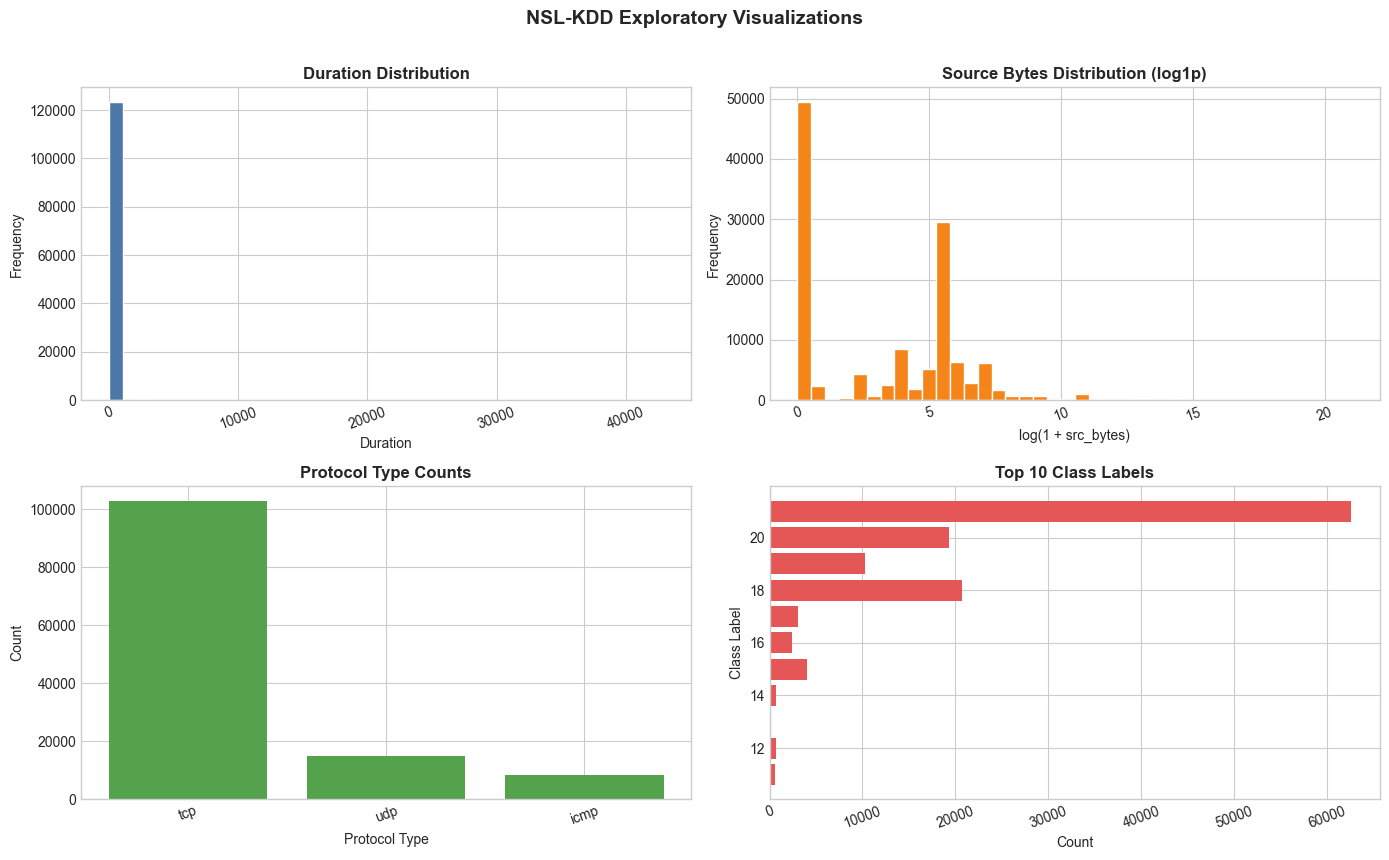

In [5]:
# Report-style plots with clearer labels and balanced scaling.
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) Duration distribution
axes[0, 0].hist(df_basic["duration"], bins=40, color="#4C78A8", edgecolor="white")
axes[0, 0].set_title("Duration Distribution", fontsize=12, weight="bold")
axes[0, 0].set_xlabel("Duration")
axes[0, 0].set_ylabel("Frequency")

# 2) Source bytes (log scale helps reduce extreme skew)
src_log = np.log1p(df_basic["src_bytes"])
axes[0, 1].hist(src_log, bins=40, color="#F58518", edgecolor="white")
axes[0, 1].set_title("Source Bytes Distribution (log1p)", fontsize=12, weight="bold")
axes[0, 1].set_xlabel("log(1 + src_bytes)")
axes[0, 1].set_ylabel("Frequency")

# 3) Protocol counts
protocol_counts = df_basic["protocol_type"].value_counts().sort_values(ascending=False)
axes[1, 0].bar(protocol_counts.index, protocol_counts.values, color="#54A24B")
axes[1, 0].set_title("Protocol Type Counts", fontsize=12, weight="bold")
axes[1, 0].set_xlabel("Protocol Type")
axes[1, 0].set_ylabel("Count")

# 4) Top class labels
top_classes = df_basic["class_label"].value_counts().head(10).sort_values(ascending=True)
axes[1, 1].barh(top_classes.index, top_classes.values, color="#E45756")
axes[1, 1].set_title("Top 10 Class Labels", fontsize=12, weight="bold")
axes[1, 1].set_xlabel("Count")
axes[1, 1].set_ylabel("Class Label")

for ax in axes.ravel():
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("NSL-KDD Exploratory Visualizations", fontsize=14, weight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

---
## Q5. KNN Model (Train/Test Split 80/20)

In [6]:
# Convert categorical text values into numeric labels.
df_model = df_basic.copy()
for col in categorical_cols:
    encoder = LabelEncoder()
    df_model[col] = encoder.fit_transform(df_model[col])

# Use all available predictors except target and difficulty level.
X = df_model.drop(["class_label", "difficulty_level"], axis=1)
y = df_model["class_label"]

k = int(input("Enter the number of neighbors (k): "))

# Split data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize features with min-max scaling based on training data.
train_min, train_max = X_train.min(), X_train.max()
train_range = train_max - train_min
train_range[train_range == 0] = 1

X_train = (X_train - train_min) / train_range
X_test = (X_test - train_min) / train_range

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-Measure:", round(f1, 4))

c:\Users\yugpa\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\yugpa\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\yugpa\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\yugpa\AppData\Local\Programs\Python\Pytho

Accuracy: 0.8591
Precision: 0.8656
Recall: 0.8591
F1-Measure: 0.8613


---
## Q6. Conclusion

This project helped me build a complete beginner-level intrusion detection workflow.

What I observed:
1. The NSL-KDD dataset is large and clearly imbalanced across class labels.
2. For this dataset, row dropping was not needed, and keeping all rows is safer for model performance.
3. Simple preprocessing (encoding + scaling) was enough to train a working KNN baseline.
4. The model gives a good starting accuracy, and this can be improved later with feature selection or better models.